In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from brian2 import *

In [2]:
seed(0)

In [ ]:
defaultclock.dt = 1*ms

eqs_neurons = '''
r = int(u >= 0) * u * Hz : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r) : Hz
du/dt = 1 / Tau * (-u + u_syn + r_ext) : 1
r_ext : 1
u_syn : 1
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : 1 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
delta_w = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz 
ddelta_w_slow/dt = (delta_w - delta_w_slow) / Tau_W : Hz (clock-driven)
dw/dt = Lr * (delta_w_slow) + Sigma_wr * xi : 1 (clock-driven)
theta = (r_slow_post)**2 / R_0 : Hz (constant over dt)
u_syn_post = w * r_pre / Hz : 1 (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
A_ltd : 1 (constant) 
R_0 : Hz (constant)
Tau_W : second (constant)
Sigma_wr : Hz**0.5 (constant)
'''

In [4]:
LR = 1e-3

In [5]:
def init_network(w_init, n_inputs, t_init):
    all_neurons = NeuronGroup(n_inputs + 1, eqs_neurons, method='euler')
    input_neurons = all_neurons[:n_inputs]
    output_neuron = all_neurons[n_inputs]
    synapses = Synapses(input_neurons, output_neuron, eqs_syn, method='euler')
    synapses.connect()
    
    input_neurons.r_ext = 1.
    all_neurons.Tau_slow = 500*ms
    all_neurons.Tau = 10*ms
    all_neurons.u = 2
    
    synapses.R_0 = 2*Hz
    synapses.w = f'0.05*rand()'
    synapses.w[0] = w_init
    synapses.w[1:] = synapses.w[1:] / sum(synapses.w[1:]) * (0.75-w_init)
    synapses.Lr = LR
    synapses.Lr[0] = 0.
    synapses.A_ltd = 1.
    synapses.Tau_W = 1000*ms
    synapses.Sigma_wr = 0
    
    dt_record = 20*ms
    M = StateMonitor(all_neurons, ['r'], record=True, dt=dt_record)
    S = StateMonitor(synapses, ['w', 'theta'], record=True, dt=dt_record)
    
    net = Network(synapses, all_neurons, M, S)
    
    net.run(t_init)
    net.store("init_5_min")
    
    return net, input_neurons, output_neuron, synapses, M, S

def random_stimulation(network, tau_slow):
    network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 5 + 1
    network["net"].run(4*second)
    network["input_neurons"][0:1].r_ext = 1
    network["net"].run(5*second)
    network["net"].store(f"post_random_{tau_slow/second:.2f}")
    return network["synapses"].w[0]
    
def sync_stimulation(network, tau_slow):
    network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 100 * 0.5 + 1
    network["net"].run(0.1*second)
    network["input_neurons"][0:1].r_ext = 1
    network["net"].run(5*second)
    network["net"].store(f"post_sync_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

def gameplay_stimulation(network, tau_slow):
    network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 20 * 0.5 + 1
    network["net"].run(0.2*second)
    network["input_neurons"][0:1].r_ext = 1
    network["net"].run(5*second)
    network["net"].store(f"post_gameplay_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

In [6]:
w_grid = np.arange(0, 0.501, 0.05)
networks = []
for w_stim in w_grid:
    net, input_neurons, output_neuron, synapses, M, S = init_network(w_stim, 20, 500*second)
    _dict = {"input_neurons" : input_neurons,
             "output_neuron" : output_neuron,
             "synapses" : synapses,
             "net" : net,
             "M" : M,
             "S" : S,
             "w_stim": w_stim
             }
    networks.append(_dict)

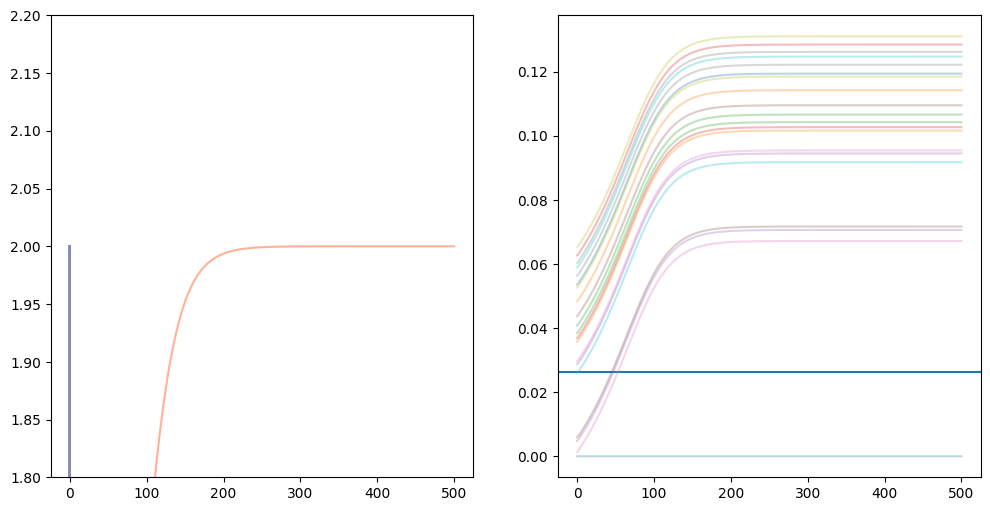

In [7]:
M = networks[0]["M"]
S = networks[0]["S"]

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(M.t, M.r[:-1].T, alpha=0.3, color='dodgerblue', linewidth=1.5)
axs[0].plot(M.t, M.r[-1].T, alpha=0.6, color='coral', linewidth=1.5)
axs[0].set_ylim(1.8, 2.2)

axs[1].axhline(0.5/19)
axs[1].plot(S.t, S.w.T, alpha=0.3, linewidth=1.5)

plt.show()

In [8]:
tau_slows = np.arange(0.2, 1.01, 0.2) * second
delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        w_random = random_stimulation(network, tau_slow)
        w_sync = sync_stimulation(network, tau_slow)
        w_gameplay = gameplay_stimulation(network, tau_slow)
        delt_ws_random[i,j] = w_random - network["w_stim"]
        delt_ws_sync[i,j] = w_sync - network["w_stim"]
        delt_ws_gameplay[i,j] = w_gameplay - network["w_stim"]

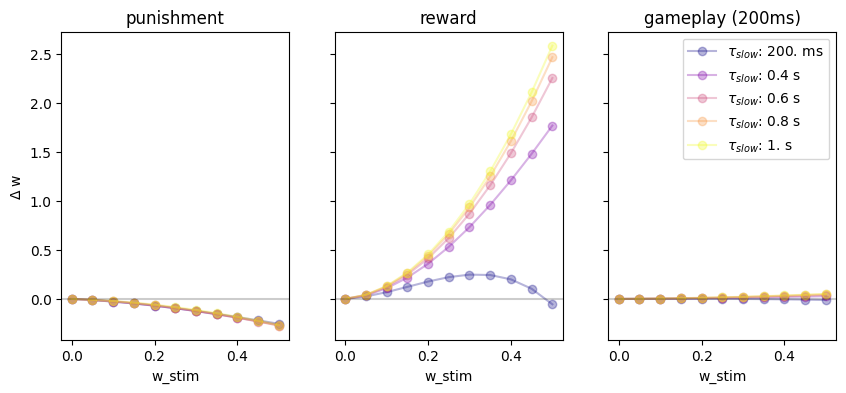

In [9]:
fig, axs = plt.subplots(1,3, figsize=(10,4), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tau_slows.min(), vmax=tau_slows.max())
for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    axs[0].plot(w_grid, delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3)
    axs[1].plot(w_grid, delta_w_sync, '-o', color=cmap(norm(tau_slow)), alpha=0.3)
    axs[2].plot(w_grid, delta_w_gameplay, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)


axs[0].set_ylabel(r'$\Delta$ w')
axs[0].set_title('punishment')
axs[1].set_title('reward')
axs[2].set_title('gameplay (200ms)')
axs[2].legend()

# axs[0].set_ylim(-0.02, 0.02)

plt.show()

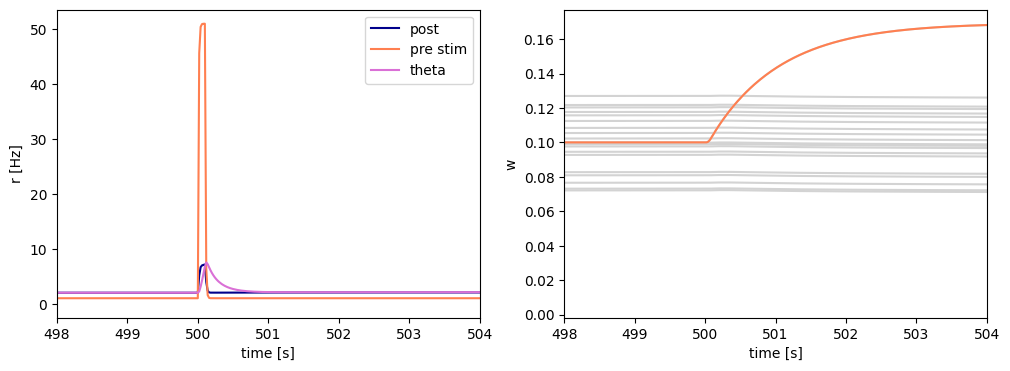

In [10]:
fig, axs = plt.subplots(1,2, figsize=(12,4),sharex=True)
network = networks[2]
network["net"].restore("post_sync_0.20")
M = network["M"]
S = network["S"]

axs[0].plot(M.t, M.r[-1].T, label='post', color='darkblue')
axs[0].plot(M.t, M.r[0].T, label='pre stim', color='coral')
axs[0].plot(S.t, S.theta[0].T, label='theta', color='orchid')
axs[0].legend()
axs[1].plot(S.t, S.w.T, alpha=1, linewidth=1.5, color='lightgray')
axs[1].plot(S.t, S.w[0].T, alpha=1, linewidth=1.5, color='coral')


for ax in axs:
    ax.set_xlabel('time [s]')
    
axs[1].set_xlim(498, 504)
axs[0].set_ylabel('r [Hz]')
axs[1].set_ylabel('w')

plt.show()